# My First SewerTris Example

This notebook walks through a complete first SewerTris workflow using the refactored `sewertris` package in `src/sewertris`. It starts from a simple domain mask, fills the domain with tetromino-style urban blocks, generates roads and topography, builds a sanitary sewer network, assigns land use and design flows, exports an EPA-SWMM model, runs inflow/RDII scenarios, and saves resulting flow components for analysis.

The notebook is organized around the twelve key SewerTris model implementation steps:

1. Urban Domain Definition: Defines the spatial modeling boundary using a vector polygon or raster mask and establishes the sewer outlet location.

2. Tetris Block Definition: Specifies modular tetromino building blocks (I, L, T, S, Z shapes) that form the geometric basis of the synthetic urban layout.

3. Stochastic Tetris Completion: Populates the domain using randomized block placement to generate heterogeneous but coherent urban configurations.

4. Road Network Extraction: Derives a synthetic road network from block boundaries, ensuring topological consistency with urban structure.

5. Land-Use Assignment: Assigns residential, commercial, industrial, public, and recreational land uses using rule-based or user-defined allocation strategies.

6. Synthetic DEM Generation: Creates a hydraulically consistent Digital Elevation Model (DEM) enforcing global drainage toward the outlet.

7. Sewer Network Generation: Constructs a gravity-driven, tree-structured sewer network aligned with roads and embedded within the DEM.

8. Sewer Flow Predesign: Computes baseline peak discharges combining Dry-Weather Flow (DWF), Groundwater Infiltration (GWI), and Rainfall-Derived Inflow & Infiltration (RDII).

9. Pipe Sizing and Hydraulic Properties: Assigns pipe diameters, roughness, and invert elevations using Manning-based design principles.

10. Dynamic Flow Input Definition: Specifies temporally resolved DWF, GWI, and RDII inputs, including rainfall forcing and spatial heterogeneity options.

11. EPA-SWMM Simulation: Performs unsteady hydraulic routing and enables component tagging (RAIN and DRY) for flow separation analysis.

12. Flow Output Decomposition: Extracts and decomposes total flows into DWF, RDII, and residual GWI components for benchmarking and diagnostics.


## Setup: Import Libraries

This cell imports the scientific Python stack and adds the repository `src` directory to `sys.path`, so the notebook uses the refactored `sewertris` package directly.

In [16]:
import os
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from pyproj import Transformer

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris as sp


## 1. Urban Domain Definition

Defines the spatial modeling boundary using a vector polygon or raster mask and establishes the sewer outlet location. This example uses a manual raster-style `domain_mask`, but the same workflow can be adapted to a shapefile boundary.

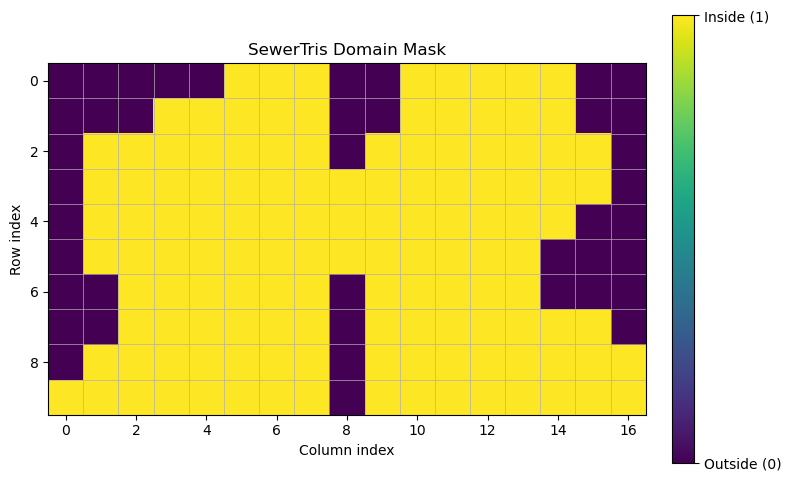

In [17]:
# --- Parameters ---
min_width = 100  # meters
use_shapefile = False  # Set to False to use manual domain_mask
# shapefile_path = "path/to/your/basin_shapefile.shp"  # Update with your shapefile path
if use_shapefile:
    # Read shapefile (assumed WGS84)
    gdf = gpd.read_file(shapefile_path)
    gdf = gdf.to_crs("EPSG:4326")
    # Get bounds in WGS84
    minx, miny, maxx, maxy = gdf.total_bounds
    # Project to UTM for metric calculations
    utm_crs = gdf.estimate_utm_crs()
    gdf_utm = gdf.to_crs(utm_crs)
    minx_utm, miny_utm, maxx_utm, maxy_utm = gdf_utm.total_bounds
    width_m = maxx_utm - minx_utm
    height_m = maxy_utm - miny_utm
    n_cols = int(np.ceil(width_m / min_width))
    n_rows = int(np.ceil(height_m / min_width))
    # Create grid in UTM
    x_edges = np.linspace(minx_utm, maxx_utm, n_cols+1)
    y_edges = np.linspace(miny_utm, maxy_utm, n_rows+1)
    # Prepare transformer for grid cell centers
    transformer = Transformer.from_crs(utm_crs, "EPSG:4326", always_xy=True)
    domain_mask = np.zeros((n_rows, n_cols), dtype=int)
    for i in range(n_rows):
        for j in range(n_cols):
            # Cell center in UTM
            cx = 0.5 * (x_edges[j] + x_edges[j+1])
            cy = 0.5 * (y_edges[i] + y_edges[i+1])
            # Transform to WGS84
            lon, lat = transformer.transform(cx, cy)
            pt = gpd.points_from_xy([lon], [lat], crs="EPSG:4326")[0]
            # Check if inside basin
            if gdf.contains(pt).any():
                domain_mask[i, j] = 1
else:
    # Manual domain_mask definition (as before)
    # Example: Top wide rectangle, bottom extra-large L
    # 1 = inside domain, 0 = outside

    domain_mask = np.array([
        [0,0,0,0,0,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
    ])

sp.plot_domain_mask(domain_mask, title="SewerTris Domain Mask")

## 2. Tetris Block Definition

Specifies modular tetromino building blocks (I, L, T, S, Z shapes) that form the geometric basis of the synthetic urban layout.

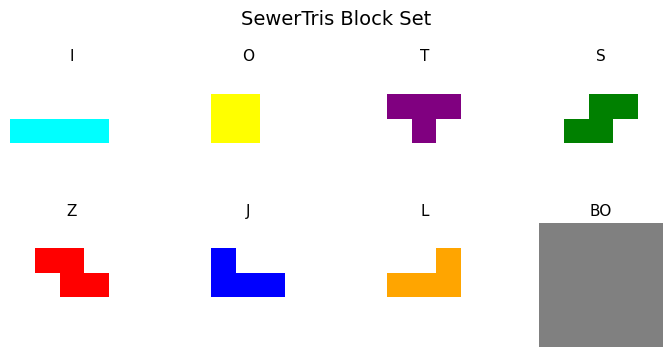

In [18]:
# Tetromino definitions (all rotations)
tetrominoes = {
    'I': [np.array([[1,1,1,1]]), np.array([[1],[1],[1],[1]])],
    'O': [np.array([[1,1],[1,1]])],
    'T': [np.array([[1,1,1],[0,1,0]]), np.array([[0,1],[1,1],[0,1]]), np.array([[0,1,0],[1,1,1]]), np.array([[1,0],[1,1],[1,0]])],
    'S': [np.array([[0,1,1],[1,1,0]]), np.array([[1,0],[1,1],[0,1]])],
    'Z': [np.array([[1,1,0],[0,1,1]]), np.array([[0,1],[1,1],[1,0]])],
    'J': [np.array([[1,0,0],[1,1,1]]), np.array([[1,1],[1,0],[1,0]]), np.array([[1,1,1],[0,0,1]]), np.array([[0,1],[0,1],[1,1]])],
    'L': [np.array([[0,0,1],[1,1,1]]), np.array([[1,0],[1,0],[1,1]]), np.array([[1,1,1],[1,0,0]]), np.array([[1,1],[0,1],[0,1]])],
    'BO': [np.array([[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]])],
}

# Assign a color to each tetromino
tetromino_colors = {
    'I': 'cyan',
    'O': 'yellow',
    'T': 'purple',
    'S': 'green',
    'Z': 'red',
    'J': 'blue',
    'L': 'orange',
    'BO': 'grey',
}

sp.plot_tetromino_set(tetrominoes, tetromino_colors, ncols=4)

## 3. Stochastic Tetris Completion

Populates the domain using randomized block placement to generate heterogeneous but coherent urban configurations, then exports the resulting blocks as geospatial polygons.

Total blocks: 52
✅ Exported 51 figures to /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/City_1.shp


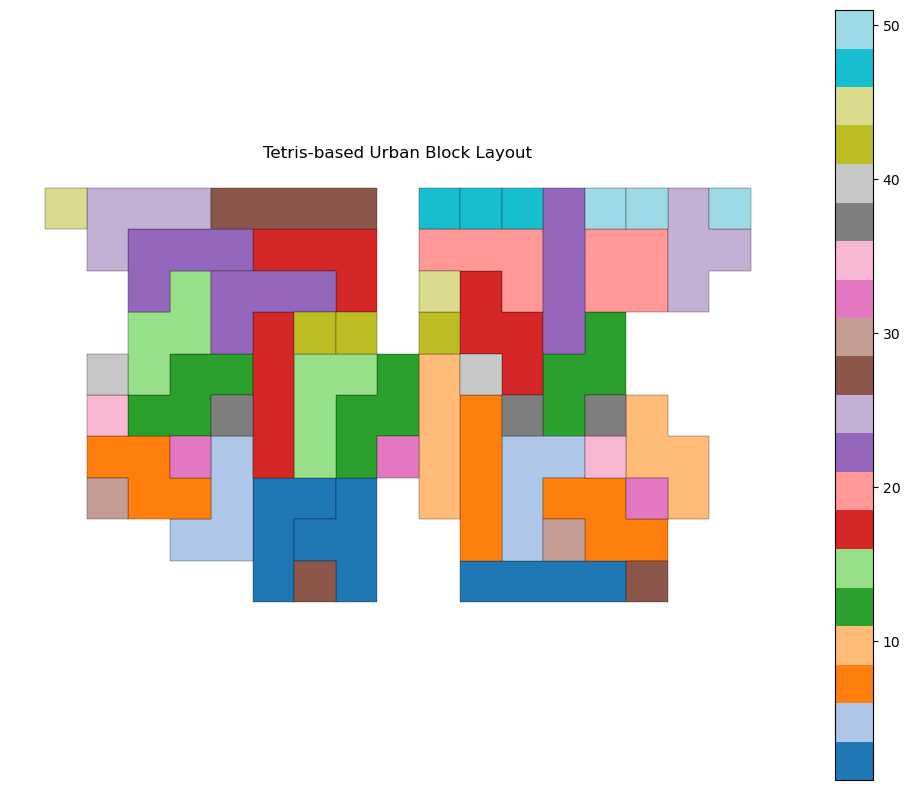

In [19]:
layout_seed = 1000
random.seed(layout_seed)
np.random.seed(layout_seed)

# Fill the domain with tetrominoes and blocks
filled_board, id_type_map, block_id = sp.fill_domain_with_tetrominoes_and_blocks(domain_mask, tetrominoes)
print("Total blocks:", len(np.unique(filled_board)))
# Export the filled board to a shapefile
output_folder = EXAMPLES_DIR / "output_example_1"
os.makedirs(output_folder, exist_ok=True)  # Create if it doesn't exist
output_shapefile = os.path.join(output_folder, "City_1.shp")
cell_size_meters = min_width  # Cell size in meters
sp.export_individual_figures_to_shapefile(
    filled_board=filled_board,
    cell_size=cell_size_meters,
    output_path=output_shapefile,
    id_to_type_map=id_type_map,
    crs="EPSG:3857",
    flip_y=True  # Set to True if you want to flip Y-axis (N/S orientation) --- IGNORE ---
)
sp.plot_filled_board_shapefile(output_shapefile)

## 4. Road Network Extraction

Derives a synthetic road network from block boundaries, ensuring topological consistency with the generated urban structure.

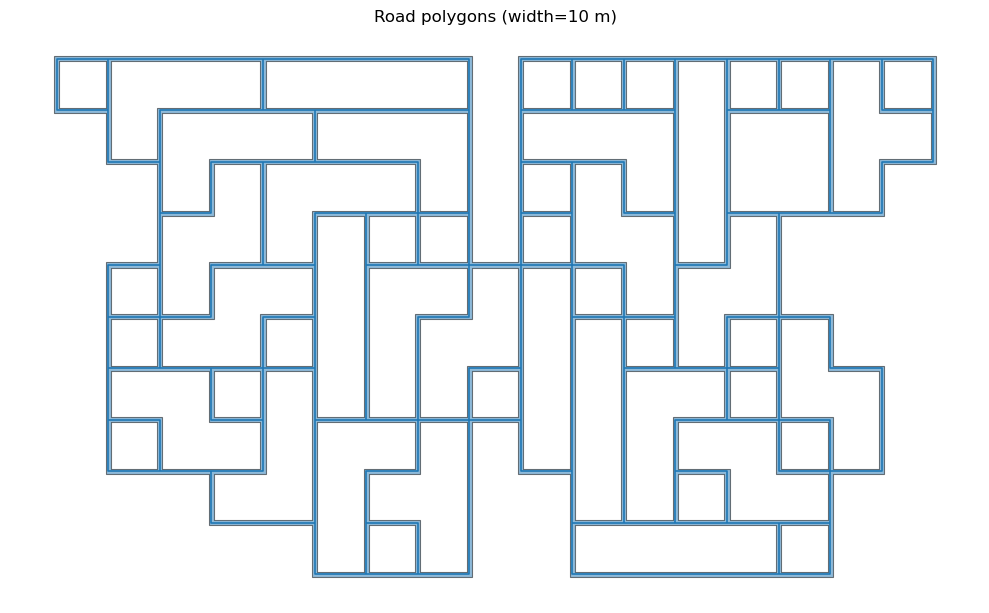

In [20]:
# Generate road network from blocks
road_width = 10  # Width of the road in meters
road_lines, road_buffer, crs = sp.generate_road_network_from_blocks(
    blocks_path=output_shapefile,
    road_width=road_width,          # road width in meters
    simplify_tol=0.5       # optional geometry simplification
)
gpd.GeoDataFrame(geometry=[road_lines], crs=crs).to_file(os.path.join(output_folder,"road_centerlines.shp"))
gpd.GeoDataFrame(geometry=[road_buffer], crs=crs).to_file(os.path.join(output_folder,"road_polygons.shp"))

sp.plot_roads(
    road_lines=road_lines,
    road_buffer=road_buffer,
    crs=crs,
    title=f"Road polygons (width={road_width} m)",
)

## 5. Land-Use Assignment

Assigns residential, commercial, industrial, public, and recreational land uses using compact rule-based allocation.

✅ Exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/City_1.shp


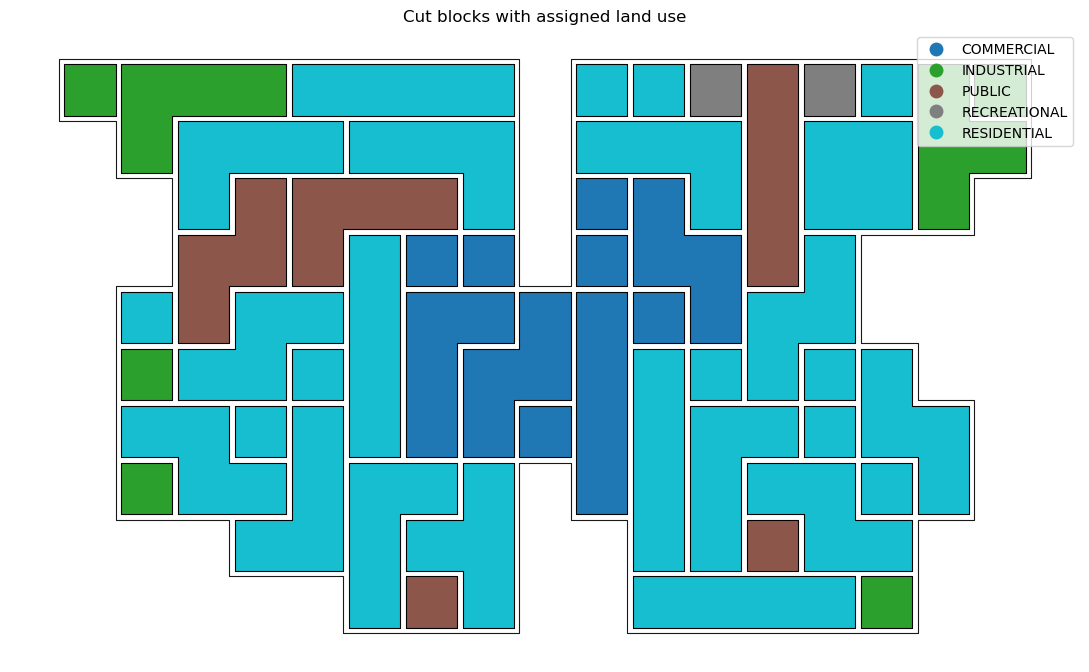

In [21]:
# Cut, label blocks and assign land use
blocks_path = output_shapefile
roads_path = os.path.join(output_folder,"road_polygons.shp")
output_path = os.path.join(output_folder,"City_1.shp")

blocks, road_network, crs = sp.load_blocks_and_roads(blocks_path, roads_path)
blocks = sp.cut_blocks(blocks, road_network)
blocks = sp.assign_land_use_compact(blocks)
gdf = sp.export_to_shapefile(blocks, crs, output_path)


# Read roads for plotting (optional but recommended)
roads_gdf = gpd.read_file(roads_path)
if roads_gdf.crs != gdf.crs:
    roads_gdf = roads_gdf.to_crs(gdf.crs)

# Plot
sp.plot_blocks_landuse(
    blocks_gdf=gdf,
    roads_gdf=roads_gdf,
    landuse_col="land_use",   # ← FIX
    title="Cut blocks with assigned land use",
    savepath=os.path.join(output_folder, "blocks_landuse.png")
)

## 6. Synthetic DEM Generation

Creates a hydraulically consistent Digital Elevation Model (DEM) enforcing global drainage toward the configured outlet direction.

[OK] Boundary lines written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/road_boundary_lines.shp
[OK] Outer shell polygon(s) written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/road_outer_shell.shp
Original boundary CRS: EPSG:3857
Original roads CRS: EPSG:3857

Boundary extent:
X range: -5.00 to 1705.00
Y range: -5.00 to 1005.00
Boundary CRS: EPSG:3857
Boundary bounds: [  -5.   -5. 1705. 1005.]
Grid shape: (122, 192)
Grid extent:
  X: -110.00 to 1810.00
  Y: -110.00 to 1110.00
Creating mask...
Processing row 0 of 122
Processing row 100 of 122
Outlet cell: (57, 20)
Computing geodesic distances...
Processing roads...


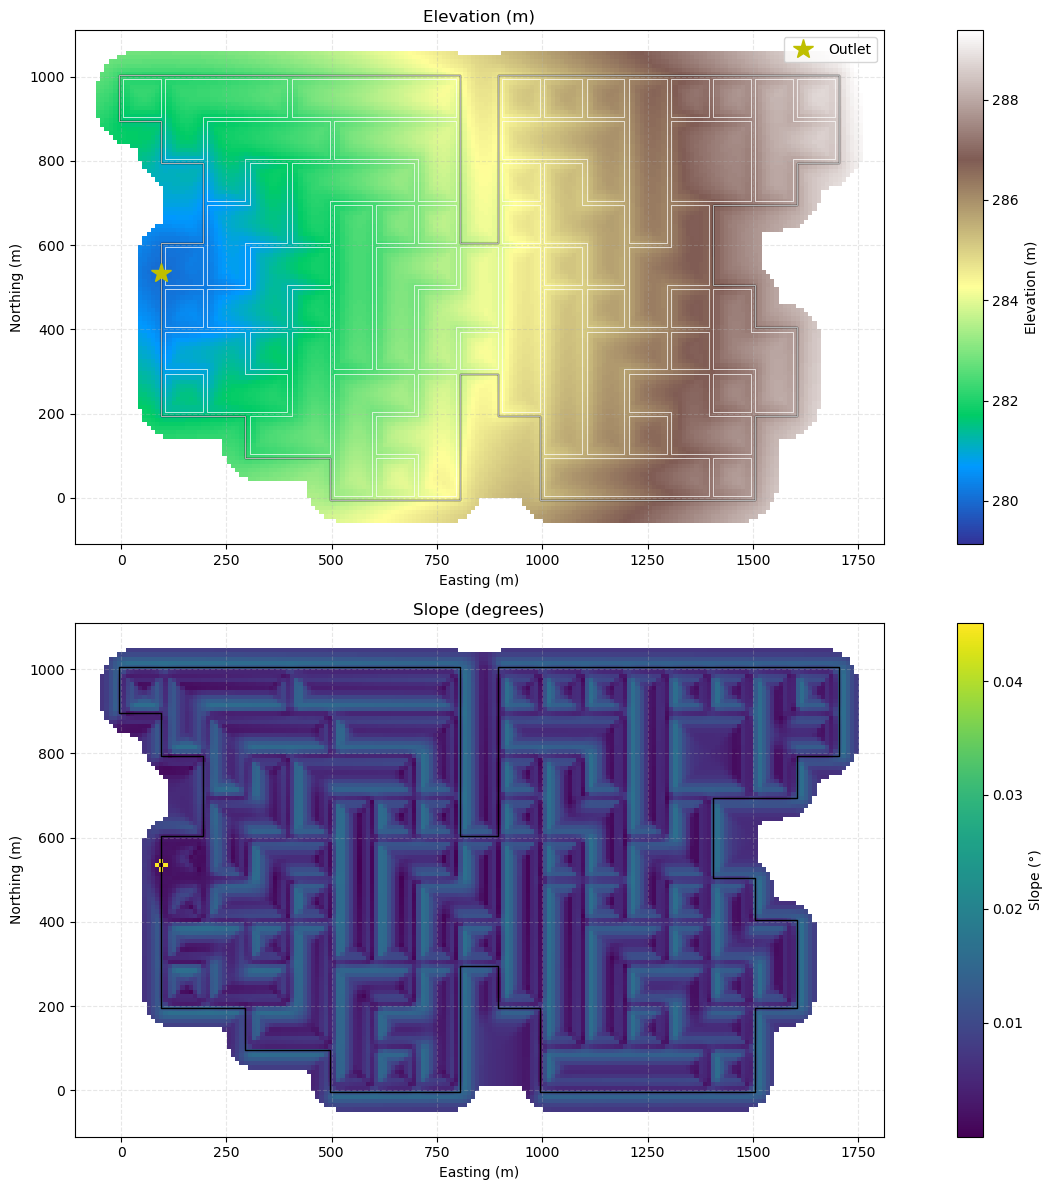


Terrain Statistics:
Elevation range: 279.14m - 289.38m
Mean elevation: 284.42m
Mean slope: 0.01°
Max slope: 0.05°

Drainage Statistics:
Points with proper drainage: 17278.0 out of 19926 (86.7%)
Using CRS: EPSG:3857
Topography successfully generated and saved to /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/generated_topography.tif
DEM resolution: 10m
Elevation range: 280m - 290m
Output CRS: EPSG:3857
Grid extent: 
  X: -110.00 to 1810.00
  Y: 1110.00 to -110.00


In [22]:
# Extract road boundaries
roads_path = os.path.join(output_folder,"road_polygons.shp")
sp.extract_boundary(
    roads_path,
    out_boundary_lines=os.path.join(output_folder,"road_boundary_lines.shp"),          # lines (outer +/- holes)
    out_outer_shell_polygon=os.path.join(output_folder,"road_outer_shell.shp"),        # polygon(s) with holes removed
    keep_holes=False                                       # only outer rings in the line output
)

# Generate topography
config = sp.TopographyConfig(
    min_elevation=280,    # meters
    max_elevation=290,    # meters
    cell_size=10,         # meters - reduced for better resolution
    outlet_direction='W', # North (N), South (S), East (E), or West (W)
    smoothing_factor=1  # Reduced for sharper drainage patterns
)

# File paths for Stillwater data
boundary_path = os.path.join(output_folder,"road_outer_shell.shp")
roads_path = os.path.join(output_folder,"road_polygons.shp")

# Ensure input files exist
if not os.path.exists(boundary_path) or not os.path.exists(roads_path):
    raise FileNotFoundError("Input shapefiles not found. Please check the file paths.")

try:
    # Generate topography
    elevation, xx, yy, mask = sp.generate_topography(boundary_path, roads_path, config)
    
    # Get the CRS from the input data
    boundary_gdf = gpd.read_file(boundary_path)
    input_crs = boundary_gdf.crs
    
    if input_crs is None:
        print("Warning: Input CRS is None, defaulting to UTM Zone 14N (EPSG:32614)")
        input_crs = "EPSG:32614"  
    
    print(f"Using CRS: {input_crs}")
    
    # Save the resulting DEM as a GeoTIFF
    output_path = os.path.join(output_folder, "generated_topography.tif")
    
    # Create the proper transform
    transform = rasterio.transform.from_bounds(
        west=xx[0,0],    # leftmost coordinate
        south=yy[-1,0],  # bottom coordinate
        east=xx[0,-1],   # rightmost coordinate
        north=yy[0,0],   # top coordinate
        width=elevation.shape[1],
        height=elevation.shape[0]
    )
    
    # Save with the same CRS as input data
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=elevation.shape[0],
        width=elevation.shape[1],
        count=1,
        dtype=elevation.dtype,
        crs=input_crs,
        transform=transform,
        nodata=np.nan
    ) as dst:
        # Write the data ensuring proper orientation
        dst.write(elevation, 1)
    
    print(f"Topography successfully generated and saved to {output_path}")
    print(f"DEM resolution: {config.cell_size}m")
    print(f"Elevation range: {config.min_elevation}m - {config.max_elevation}m")
    print(f"Output CRS: {input_crs}")
    print(f"Grid extent: ")
    print(f"  X: {xx[0,0]:.2f} to {xx[0,-1]:.2f}")
    print(f"  Y: {yy[0,0]:.2f} to {yy[-1,0]:.2f}")
    
except Exception as e:
    print(f"Error generating topography: {str(e)}")
    raise

## 7. Sewer Network Generation

Constructs a gravity-driven, tree-structured sewer network aligned with roads and embedded within the DEM.

✅ Extracted 135 manholes from road centerlines.
✅ Manholes exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/manholes.shp

Path Statistics:
Head: MH127  →  Target: MH086
Segments: 23
Total length: 2300.0 m
Total drop: 8.73 m
Avg slope: 0.379%
⚠️ Some manholes could not be connected while preserving constraints.
✅ Generated 61 secondary pipes.
✅ Cleaned: 0 secondary pipes removed.
Main outlet ID: MH086
Total manholes: 135
Nodes already touched by main+secondary: 85
Manholes missing outlet pipe: 50
First 20 missing: ['MH005', 'MH006', 'MH009', 'MH016', 'MH018', 'MH019', 'MH027', 'MH030', 'MH031', 'MH033', 'MH036', 'MH041', 'MH046', 'MH050', 'MH054', 'MH055', 'MH056', 'MH057', 'MH061', 'MH064']
Duplicate sources: []
📊 Initial missing outlet pipes: 50
Iteration 1: start=MH009, status=committed, chain_len=2, remaining=48
Iteration 2: start=MH033, status=committed, chain_len=1, remaining=47
Iteration 3: start=MH041, status=committed, chain_len=4, remaining=43
Itera

/Users/kevinblanco/Documents/Sewertris/src/sewertris/sewer_network.py:2583: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstream'
  ogr_write(


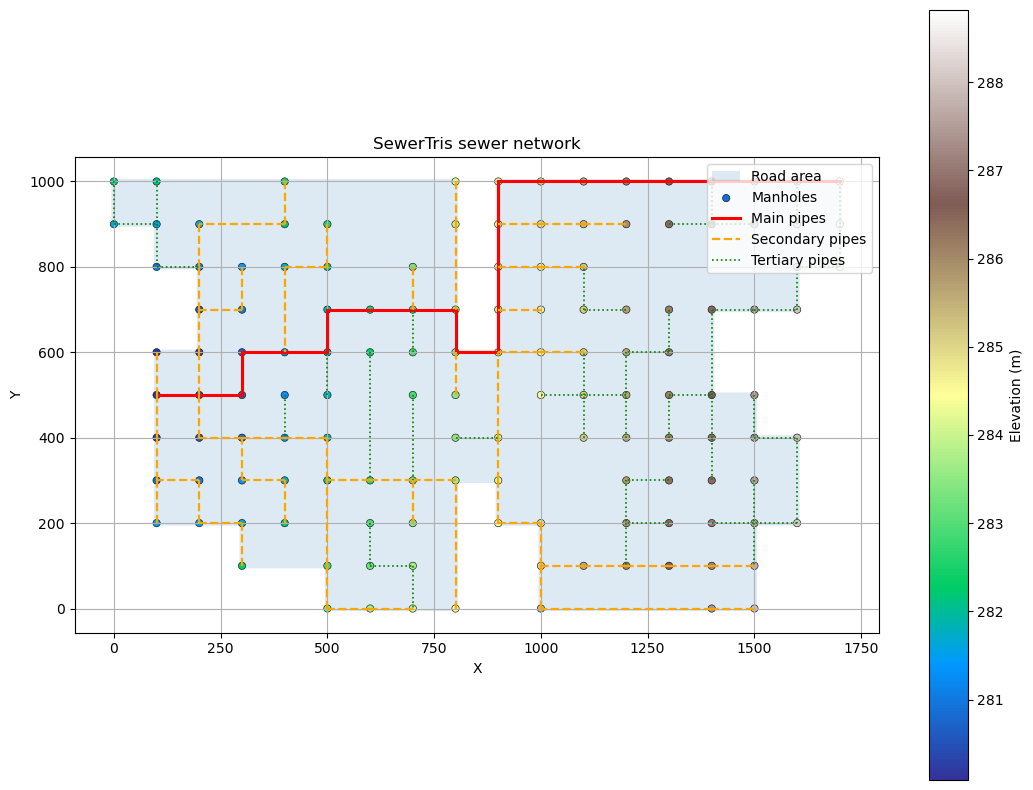

In [23]:
road_axes_path=os.path.join(output_folder,"road_centerlines.shp")
dem_path=os.path.join(output_folder,"generated_topography.tif")
manholes = sp.extract_manholes_from_lines(road_axes_path, dem_path)
sp.export_manholes_to_shapefile(manholes, os.path.join(output_folder,"manholes.shp"), crs=gpd.read_file(road_axes_path).crs)

# Generate main sewer path

road_buffer=road_lines.buffer(road_width * 0.6)

segments, path_info, graph_data = sp.generate_main_sewer_path_optimized(
    manholes=manholes,
    road_buffer=road_buffer,
    block_size=min_width*2,
    slope_tolerance=-0.01,
    min_pipe_length=5.0,
    prefer_slope=0.5,
    return_graph_data=True,
)

# Generate secondary sewer pipes

main_path = path_info["segments"]

secondary_pipes, secondary_attrs = sp.generate_secondary_pipes_optimized(
    manholes=manholes,
    main_path=main_path,
    road_buffer=road_lines.buffer(road_width * 0.6),
    block_size=min_width * 2,
    slope_tolerance=0.00,
    prefer_slope=0.5,
    return_attrs=True,
)

secondary_pipes_clean = sp.remove_secondary_pipes_overlapping_main_optimized(
    manholes=manholes,
    secondary_pipes=secondary_pipes,
    main_pipes=main_path
)

# Check Sewer Network Status

network_status = sp.build_current_network_status(
    manholes=manholes,
    main_path=main_path,
    secondary_pipes=secondary_pipes_clean,
)

print("Main outlet ID:", network_status["main_outlet_id"])
print("Total manholes:", len(network_status["all_ids"]))
print("Nodes already touched by main+secondary:", len(network_status["nodes_in_network"]))
print("Manholes missing outlet pipe:", len(network_status["missing_outlet_ids"]))
print("First 20 missing:", network_status["missing_outlet_ids"][:20])
print("Duplicate sources:", network_status["duplicate_sources"][:20])

# Generate tertiary pipes

tertiary_pipes, tertiary_unconnected, tertiary_attrs = sp.generate_tertiary_pipes_backtracking_stop_at_each_manhole(
    manholes=manholes,
    main_path=main_path,
    secondary_pipes=secondary_pipes_clean,
    road_buffer=road_lines.buffer(road_width * 0.6),
    city_boundary=os.path.join(output_folder, "road_outer_shell.shp"),
    block_size=min_width * 10,
    neighbor_radius_factor=1.5,
    min_pipe_length=1e-3,
    point_on_line_tol=0.01,
    return_attrs=True,
    max_search_depth=300,
)

# Export to shapefile

main_attrs = sp.build_main_attrs_from_path_info(path_info)

gdf_pipes = sp.export_pipes_to_shapefile_2(
    pipes_main=main_path,
    pipes_sec=secondary_pipes_clean,
    pipes_ter=tertiary_pipes,
    manholes=manholes,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    crs=crs,
    main_attrs=main_attrs,
    secondary_attrs=secondary_attrs,
    tertiary_attrs=tertiary_attrs,
)

print("✓ Sewer network generation complete.")

sp.plot_sewer_network_all(
    manholes=manholes,
    main_pipes=main_path,
    secondary_pipes=secondary_pipes_clean,
    tertiary_pipes=tertiary_pipes,
    unresolved=tertiary_unconnected,
    road_buffer=road_buffer,  # from unary_union(roads_gdf.geometry)
    title="SewerTris sewer network"
)

### Step 7 Continued: Embed the Sewer Network in the DEM

The DEM is adjusted along pipe alignments so the generated sewer network maintains positive gravity slopes.

Modifying topography to follow sewer network...
⚠️ Raster check: 81 pipes have a local slope < Smin (e.g., idx=111, slope=-0.000371).
Wrote: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/generated_topography.tif
Updated elevations for 135/135 manholes. Wrote: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/manholes.shp


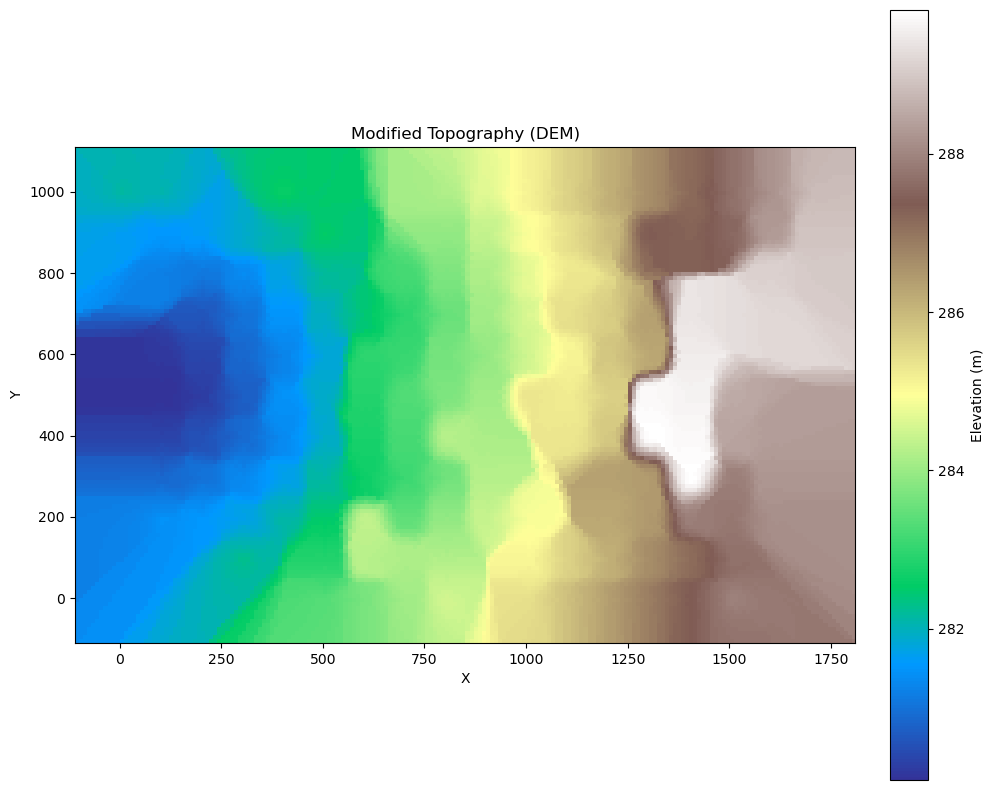

In [24]:
# Modifying topography
print("Modifying topography to follow sewer network...")

# Define paths and parameters
dem_path = os.path.join(output_folder, "generated_topography.tif")
sewer_path = os.path.join(output_folder, "sewer_pipes.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
output_path = os.path.join(output_folder, "generated_topography.tif")

out_path = sp.build_dem_with_guaranteed_positive_slopes_idw(
    dem_path=dem_path,
    pipes_path=sewer_path,
    manholes_path=manholes_path,
    output_path=output_path,
    upstream_field="upstream_m",
    downstream_field="downstream",
    manhole_id_field="id",
    manhole_elev_field="elevation",
    type_field="type",
    tier_order=("main","secondary","tertiary"),
    Smin=0.001,                                 # 0.3% min slope
    densify_step_m=None,                        # default ≈ 2 pixels
    along_pipe_weight=2,                        # small bias toward pipes
    idw_power=2.0, idw_k=12, idw_tile=1024,
    centerline_writeback=True,                  # guarantees pixel-level monotone on centerlines
    verify_on_raster=True
)
print("Wrote:", out_path)

# Update manhole elevations in the shapefile
sp.update_manhole_elevations_from_dem(
    dem_path=out_path,
    manholes_path=manholes_path,
    output_path=None,    # None + overwrite=True -> overwrite original file
    overwrite=True,
    sampling="nearest",
)

sp.plot_dem_tif(output_path, title="Modified Topography (DEM)", hillshade=False)


## 8. Sewer Flow Predesign

Computes baseline peak discharges combining Dry-Weather Flow (DWF), Groundwater Infiltration (GWI), and Rainfall-Derived Inflow & Infiltration (RDII).

In [25]:
blocks_path = os.path.join(output_folder, "City_1.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
pipes_path = os.path.join(output_folder, "sewer_pipes.shp")
topography_path = os.path.join(output_folder, "generated_topography.tif")

#🚰 LAND_USE_INFO
# For each land use category:
# - 'density' is in people per hectare [people/ha]
# - 'demand' is in liters per person per day [L/person/day]

LAND_USE_INFO = {
    'RESIDENTIAL': {
        'density': 60,     # [people/ha]
        'demand': 100       # [L/person/day]
    },
    'COMMERCIAL': {
        'density': 50,      # [people/ha] or equivalent occupancy
        'demand': 60       # [L/person/day]
    },
    'INDUSTRIAL': {
        'density': 25,      # [people/ha] or equivalent worker density
        'demand': 150       # [L/person/day]
    },
    'PUBLIC': {
        'density': 20,      # [people/ha]
        'demand': 100       # [L/person/day]
    },
    'RECREATIONAL': {
        'density': 10,      # [people/ha]
        'demand': 40        # [L/person/day]
    }
}

# Afferent areas and baseflow

sp.delineate_afferent_areas_and_baseflow(
    blocks_path=blocks_path,
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    topo_path=topography_path,
    output_path=os.path.join(output_folder, "sewer_subcatchments.shp"),
    land_use_info=LAND_USE_INFO
)

subcatchments_path = os.path.join(output_folder, "sewer_subcatchments.shp")

# Assign flow to pipes
sp.assign_flow_to_pipes_fast(
    pipes_path=pipes_path,
    subcatchments_path=subcatchments_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp")
)

# Peak flow

pipes = gpd.read_file(os.path.join(output_folder, "sewer_pipes.shp"))

# Apply BC peaking factor
peak_flow, pf = sp.british_columbia_peaking_factor(pipes["cumulative"])
pipes["peaking_factor_bc"] = pf
pipes["peak_flow_lps_bc"] = peak_flow

# Save
pipes.to_file(os.path.join(output_folder, "sewer_pipes.shp"))
print("✅ Peak flows added using BC method.")

# GWI

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.compute_gwi_cumulative(
    pipes_path=pipes_path,
    gwi_factor_ls_per_m=0.0002,            # l/s per meter
    out_path=os.path.join(output_folder,"sewer_pipes.shp"),         # or None if you don't want to write
    id_field="pipe_id",
    up_field="upstream_m",
    down_field="downstream",
    length_field=None,                     # if you already have meters in a column, put its name here
    target_crs_m="EPSG:3857"          # UTM zone for accurate length calculations
    )

# RDII

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.compute_rdii_and_accumulate(
    pipes_path=pipes_path,
    subcatch_path=subcatchments_path,
    rdii_factor_ls_per_m2=0.00002,       # L/s per m² (example)
    pipe_id_field="pipe_id",
    up_field="upstream_m",
    down_field="downstream",
    sub_pipe_field="pipe_id",            # subcatchments' field pointing to receiving pipe
    # If your subcatchments are in degrees, choose a projected CRS in meters:
    target_crs_m="EPSG:3857",
    out_pipes=os.path.join(output_folder,"sewer_pipes.shp"),
    out_subcatch=os.path.join(output_folder,"sewer_subcatchments.shp"),
)

# Predising flow

pipes_path = os.path.join(output_folder,"sewer_pipes.shp")

sp.add_predesign_flow(
    pipes_path=pipes_path,
    out_path=os.path.join(output_folder,"sewer_pipes.shp")
)



✅ Sub-catchments saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_subcatchments.shp
✅ Updated pipe file saved: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_pipes.shp
✅ Peak flows added using BC method.


/Users/kevinblanco/Documents/Sewertris/src/sewertris/hydrology.py:70: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  output.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'base_flow_lps' to 'base_flow_'
  ogr_write(
/Users/kevinblanco/Documents/Sewertris/src/sewertris/hydrology.py:263: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_1'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'own_flow_lps' to 'own_flow_l'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/

,pipe_id,upstream_m,downstream,type,dist_m,slope,cost,downstre_1,own_flow_l,cumulative,...,length_m,own_gwi_ls,cum_gwi_ls,downstre_3,own_rdii_l,cum_rdii_l,geometry,downstream_m,predesign_ls,predesign_
0,P00000,MH127,MH002,main,100.0,0.006071,100.0,MH002,0.008789,0.521688,...,100.0,0.02,0.26,MH002,0.040500,1.693619,"LINESTRING (1700 1000, 1600 1000)",MH002,4.040373,4.040373
1,P00001,MH002,MH079,main,100.0,0.005254,100.0,MH079,0.015842,0.582724,...,100.0,0.02,0.30,MH079,0.073000,1.974869,"LINESTRING (1600 1000, 1500 1000)",MH079,4.605764,4.605764
2,P00002,MH079,MH101,main,100.0,0.005218,100.0,MH101,0.021094,0.603817,...,100.0,0.02,0.32,MH101,0.060750,2.035619,"LINESTRING (1500 1000, 1400 1000)",MH101,4.770889,4.770889
3,P00003,MH101,MH078,main,100.0,0.005174,100.0,MH078,0.001406,0.810224,...,100.0,0.02,0.40,MH078,0.060750,2.890012,"LINESTRING (1400 1000, 1300 1000)",MH078,6.530908,6.530908
4,P00004,MH078,MH099,main,100.0,0.005120,100.0,MH099,0.015104,0.825328,...,100.0,0.02,0.42,MH099,0.130500,3.020512,"LINESTRING (1300 1000, 1200 1000)",MH099,6.741825,6.741825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,P00129,MH027,MH069,tertiary,100.0,0.000633,100.0,MH069,0.114280,0.114280,...,100.0,0.02,0.02,MH069,0.329127,0.329127,"LINESTRING (1100 400, 1100 500)",MH069,0.806247,0.806247
130,P00130,MH074,MH029,tertiary,100.0,-0.001295,100.0,MH029,0.064988,0.064988,...,100.0,0.02,0.02,MH029,0.187167,0.187167,"LINESTRING (400 500, 400 400)",MH029,0.467120,0.467120
131,P00131,MH115,MH068,tertiary,100.0,-0.001354,100.0,MH068,0.113529,0.214281,...,100.0,0.02,0.04,MH068,0.326962,0.617129,"LINESTRING (1200 300, 1200 200)",MH068,1.514252,1.514252
132,P00132,MH129,MH115,tertiary,100.0,0.005739,100.0,MH115,0.100752,0.100752,...,100.0,0.02,0.02,MH115,0.290167,0.290167,"LINESTRING (1300 300, 1200 300)",MH115,0.713176,0.713176


## 9. Pipe Sizing and Hydraulic Properties

Assigns pipe slopes, diameters, roughness values, materials, and invert elevations using design rules compatible with Manning-based hydraulic sizing.

/Users/kevinblanco/Documents/Sewertris/src/sewertris/design.py:82: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_5'
  ogr_write(
/Users/kevinblanco/Documents/Sewertris/src/sewertris/design.py:217: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_6'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'calc_diameter_mm' to 'calc_diame'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py

✅ Pipe slopes assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_pipes.shp
✅ Materials and diameters assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_pipes.shp
✅ Invert elevations assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_pipes.shp
✅ Pipes saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_pipes.shp
✅ Manholes saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/manholes.shp


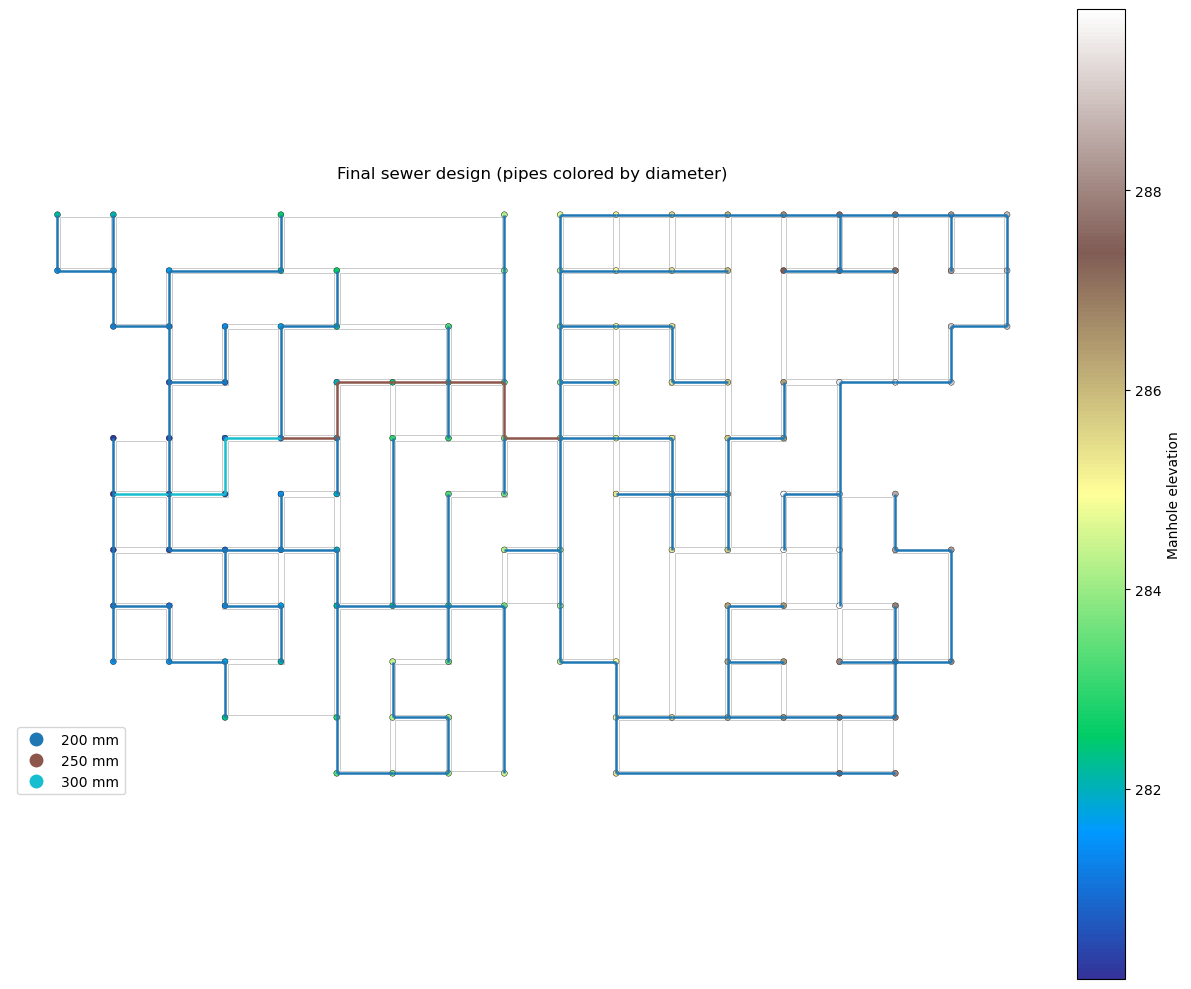

In [26]:
# Pipe slopes

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.assign_pipe_slopes(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    minimum_slope=0.005  # Can be adjusted per local design standards
)

# Pipe Diameter and material

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.assign_material_diameter_to_pipes(
    pipes_path=pipes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    material_fractions={"PVC": 0.6, "CONCRETE": 0.3, "HDPE": 0.1},
    n_by_material={"PVC": 0.011, "CONCRETE": 0.013, "HDPE": 0.012},
    standard_diameters_mm=[200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000],
    minimum_diameter_mm=200
)

# Pipe Invert Elevations

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.assign_invert_elevations(
    pipes_path=pipes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    min_cover=1.4,
    min_slope=0.005,
    manhole_drop=0.05
)

# Preprocess pipes and manholes

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.preprocess_pipes_and_manholes(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_pipes_path=os.path.join(output_folder, "sewer_pipes.shp"),
    output_manholes_path=os.path.join(output_folder, "manholes.shp")
)

final_pipes = os.path.join(output_folder, "sewer_pipes.shp")
final_mhs   = os.path.join(output_folder, "manholes.shp")
    
sp.plot_final_design_color_by_diameter(
    pipes_path=final_pipes,
    manholes_path=final_mhs,
    blocks_path=blocks_path,  # optional
    diameter_field="diameter_m",   # change if your field name differs
    manhole_color_field="elevation",  # optional; change if needed
    linewidth=1.8,
)

## 10. Dynamic Flow Input Definition

Specifies temporally resolved DWF, GWI, and RDII inputs, including daily/hourly patterns, baseline infiltration, rainfall forcing, and subcatchment routing.

In [73]:
# Export to SWMM INP format

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
options = {
    "FLOW_UNITS": "LPS",
    "INFILTRATION": "CURVE_NUMBER",
    "FLOW_ROUTING": "KINWAVE",
    "LINK_OFFSETS": "DEPTH",
    "MIN_SLOPE": "0",
    "ALLOW_PONDING": "NO",
    "SKIP_STEADY_STATE": "NO",
    "START_DATE": "01/01/2025",
    "START_TIME": "00:00:00",
    "REPORT_START_DATE": "01/01/2025",
    "REPORT_START_TIME": "00:00:00",
    "END_DATE": "01/10/2025",
    "END_TIME": "00:00:00",
    "SWEEP_START": "01/01",
    "SWEEP_END": "12/31",
    "DRY_DAYS": "0",
    "REPORT_STEP": "00:15:00",
    "WET_STEP": "00:00:01",
    "DRY_STEP": "00:00:01",
    "ROUTING_STEP": "0:00:01",
    "RULE_STEP": "00:00:00",
    "INERTIAL_DAMPING": "PARTIAL",
    "NORMAL_FLOW_LIMITED": "BOTH",
    "FORCE_MAIN_EQUATION": "D-W",
    "VARIABLE_STEP": "0.75",
    "LENGTHENING_STEP": "0",
    "MIN_SURFAREA": "1.167",
    "MAX_TRIALS": "8",
    "HEAD_TOLERANCE": "0.0015",
    "SYS_FLOW_TOL": "5",
    "LAT_FLOW_TOL": "5",
    "MINIMUM_STEP": "0.5",
    "THREADS": "1"
}

sp.export_swmm_inp(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    options_dict=options
)

✅ SWMM .inp file written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_model.inp


✅ Updated [DWF] with patterns "1" "2" "3" "4"
✅ Rewrote [PATTERNS] with HOURLY, DAILY, MONTHLY, WEEKEND
   Output saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_model.inp
✅ SWMM INP file with DWF patterns created.


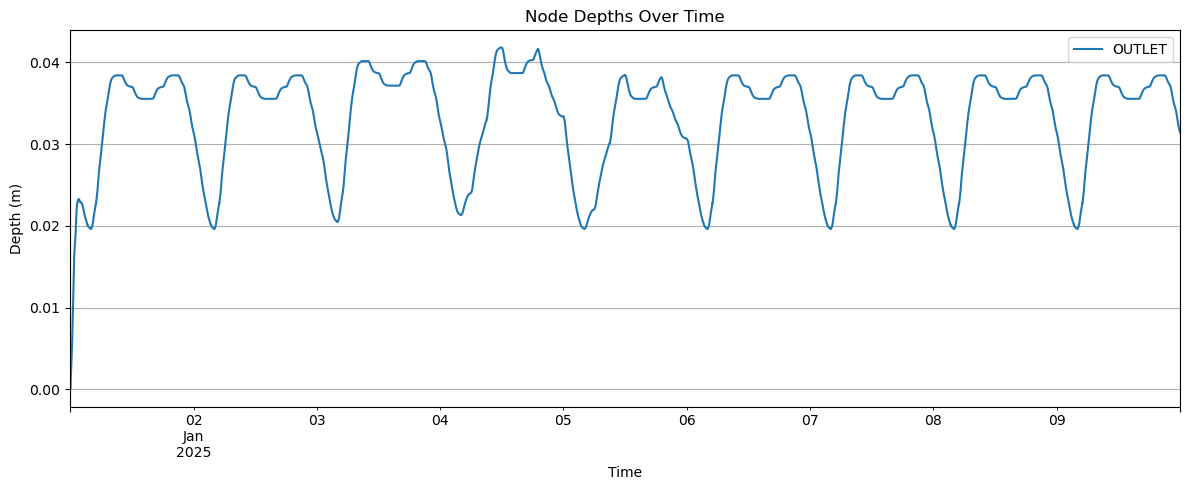

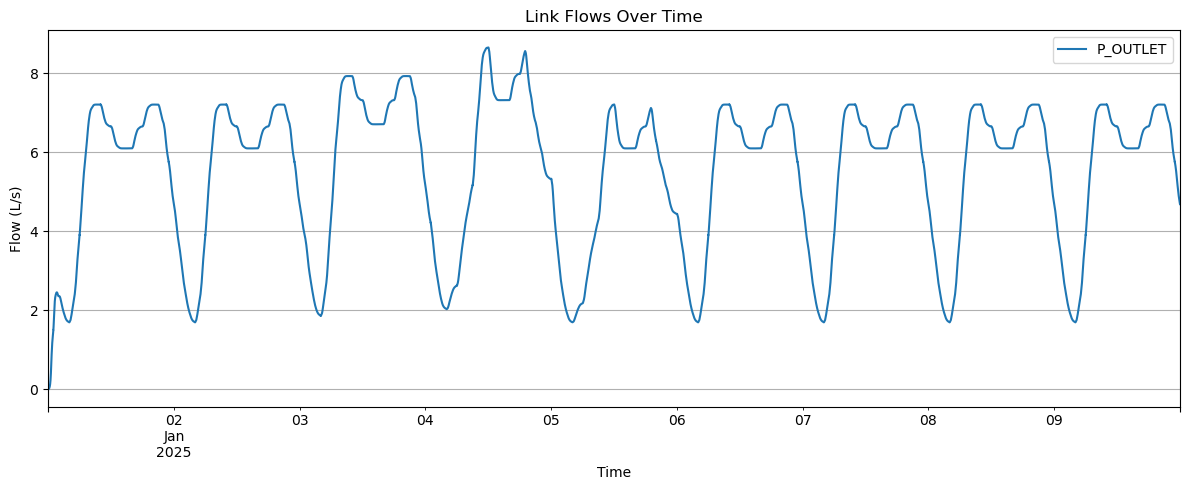

In [74]:
# BWF Patterns

SWMM_INPUT_FILE = os.path.join(output_folder, "sewer_model.inp")

# Define BWF patterns

hourly = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.4838, 0.8014,
    1.1337, 1.3239, 1.3321, 1.2512, 1.1900, 1.1703,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.3362, 1.3175, 1.1978, 0.9890, 0.7576
]

daily_vals = [1.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.2]  # Mon..Sun

monthly_vals = [  # Jan..Dec
    0.90, 0.95, 1.00, 1.05,
    1.10, 1.10, 1.05, 1.00,
    0.95, 0.90, 0.90, 0.90,
]

fairfax_weekend = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.3568, 0.4068,
    0.6068, 0.7068, 0.8014, 1.1337, 1.3239, 1.3321,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.1362, 1.0175, 0.8978, 0.8090, 0.7576
]

# Assign DWF patterns to the SWMM model
sp.assign_all_dwf_patterns(
    inp_path=SWMM_INPUT_FILE,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    hourly_id="1",
    hourly_values=hourly,
    daily_id="2",
    daily_values=daily_vals,
    monthly_id="3",
    monthly_values=monthly_vals,
    weekend_id="4",
    weekend_values=fairfax_weekend
)

print("✅ SWMM INP file with DWF patterns created.")

nodes_to_monitor = ["OUTLET"]
links_to_monitor = ["P_OUTLET"]

depths_df, flows_df = sp.run_swmm_and_plot(os.path.join(output_folder, "sewer_model.inp"), monitored_nodes=nodes_to_monitor, monitored_links=links_to_monitor)


✅ INFLOWS section created using coefficient 0.0001. File saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_model.inp


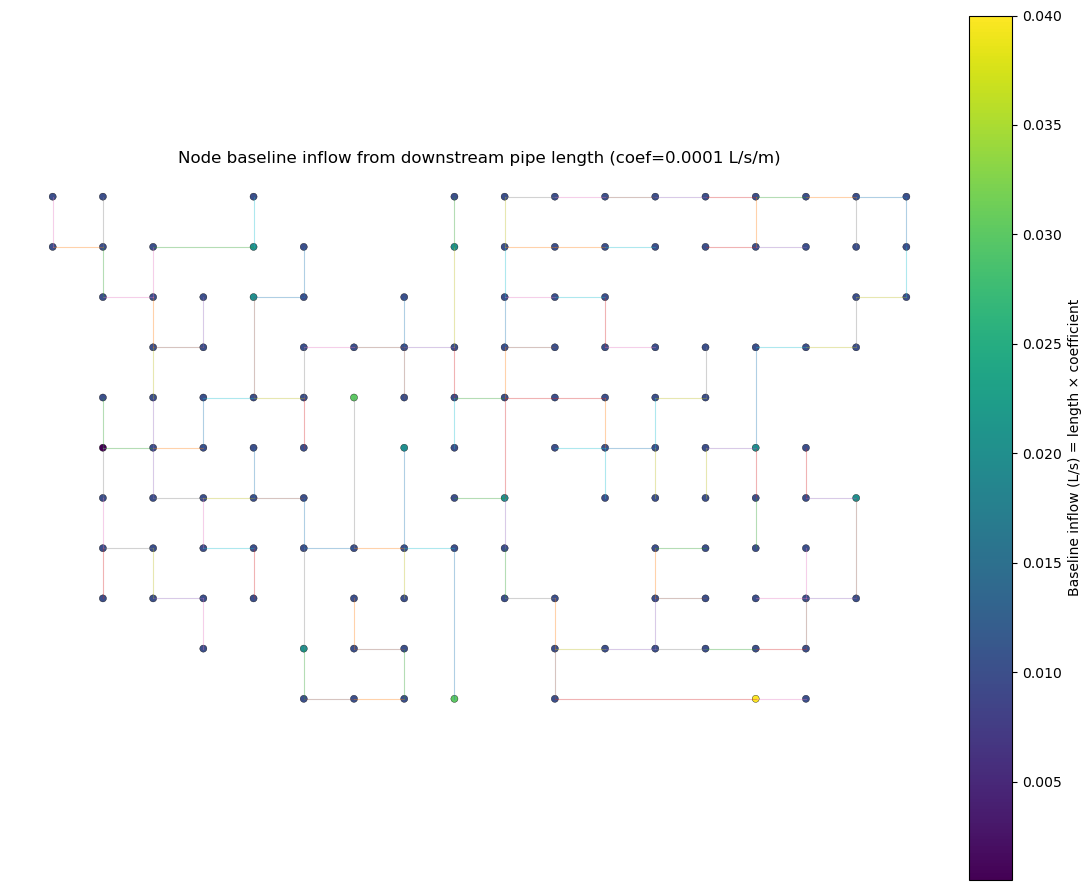

Nodes plotted: 135
Inflow range: 0.0005 to 0.0400 L/s


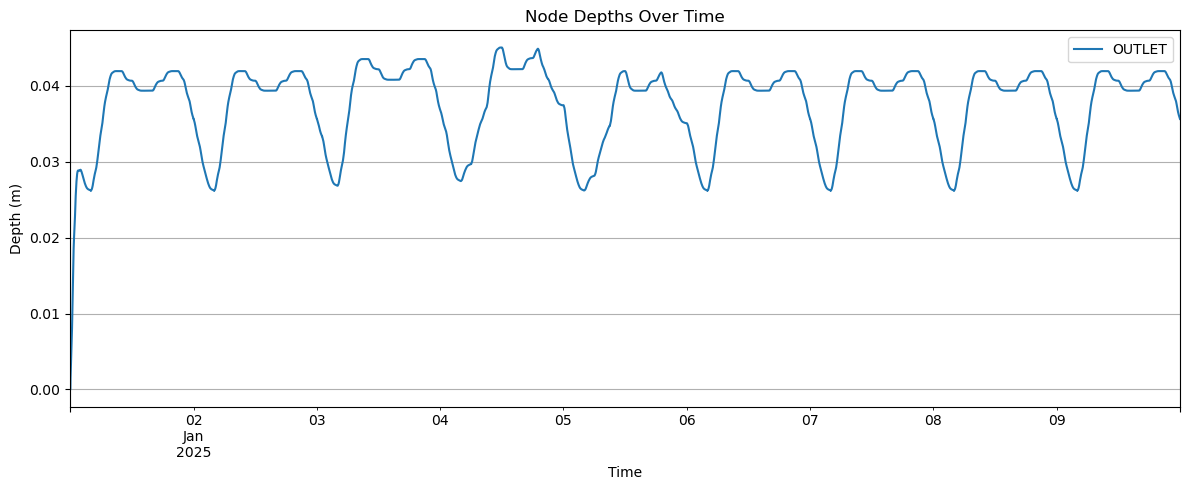

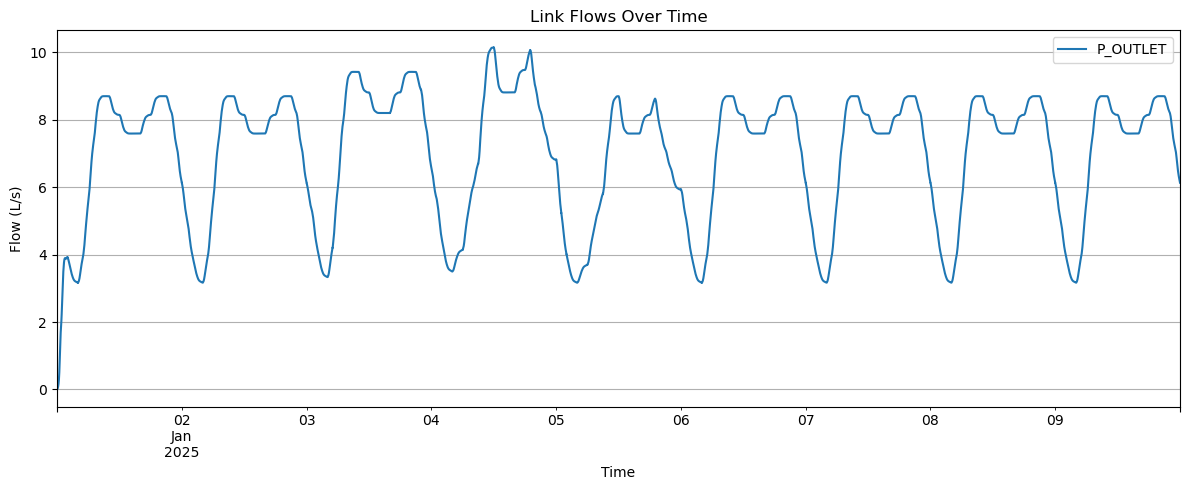

In [75]:
# GWI

inp_file = os.path.join(output_folder, "sewer_model.inp")

sp.assign_inflow_from_pipe_length(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    coefficient=0.0001  # LPS per meter
)

inp_file = os.path.join(output_folder, "sewer_model.inp")
sp.plot_inflow_from_pipe_length(
    inp_path=inp_file,
    coefficient=0.0001,
)

nodes_to_monitor = ["OUTLET"]
links_to_monitor = ["P_OUTLET"]

depths_df, flows_df = sp.run_swmm_and_plot(os.path.join(output_folder, "sewer_model.inp"), monitored_nodes=nodes_to_monitor, monitored_links=links_to_monitor)


rainfall_data=[
    ('1/2/2025', '00:00', 0.0),
    ('1/2/2025', '01:00', 0.055),
    ('1/2/2025', '02:00', 0.055),
    ('1/2/2025', '03:00', 0.065),
    ('1/2/2025', '04:00', 0.065),
    ('1/2/2025', '05:00', 0.075),
    ('1/2/2025', '06:00', 0.085),
    ('1/2/2025', '07:00', 0.095),
    ('1/2/2025', '08:00', 0.105),
    ('1/2/2025', '09:00', 0.135),
    ('1/2/2025', '10:00', 0.17),
    ('1/2/2025', '11:00', 0.27),
    ('1/2/2025', '12:00', 2.14),
    ('1/2/2025', '13:00', 0.545),
    ('1/2/2025', '14:00', 0.24),
    ('1/2/2025', '15:00', 0.17),
    ('1/2/2025', '16:00', 0.13),
    ('1/2/2025', '17:00', 0.11),
    ('1/2/2025', '18:00', 0.095),
    ('1/2/2025', '19:00', 0.085),
    ('1/2/2025', '20:00', 0.07),
    ('1/2/2025', '21:00', 0.065),
    ('1/2/2025', '22:00', 0.06),
    ('1/2/2025', '23:00', 0.06),
    ('1/3/2025', '00:00', 0.055),
]
✅ SWMM .inp file updated with subcatchments and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_model.inp


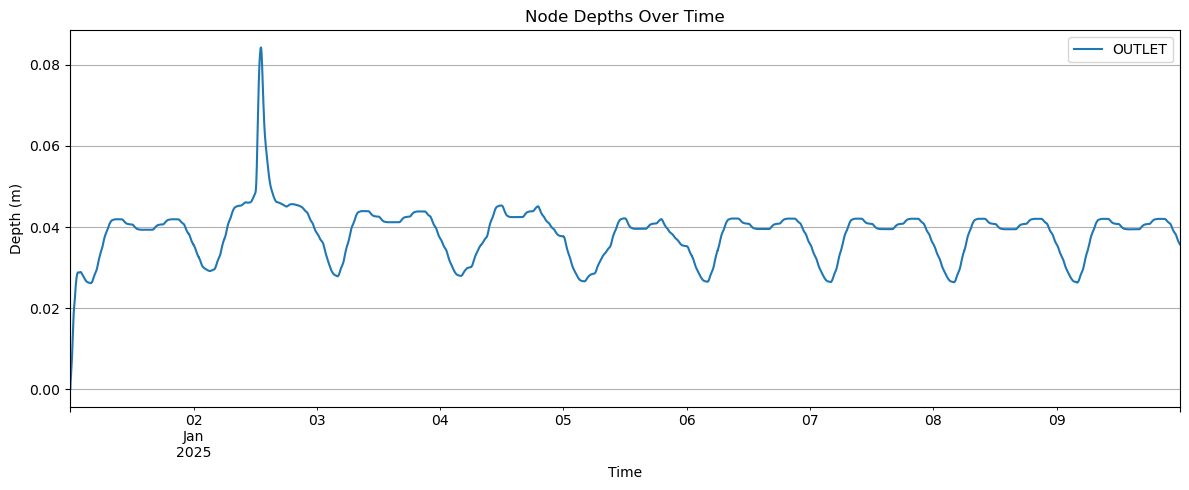

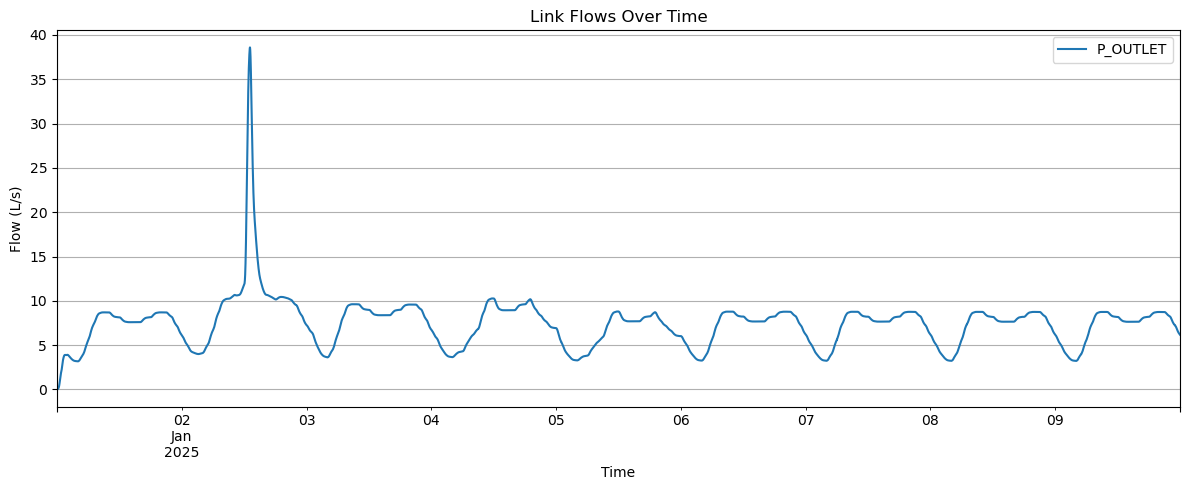

In [76]:
# RDII

inp_file = os.path.join(output_folder, "sewer_model.inp")

# rainfall_seed = 42

# # Time Series Generation
# rainfall_data = sp.generate_clustered_rainfall_timeseries(
#     start_date="2025-01-01 00:00",
#     end_date="2025-02-01 00:00",
#     timestep_minutes=15,
#     avg_annual_precip_mm=1200,
#     wet_season_months=[4, 5, 6, 9, 10, 11],
#     dry_wet_ratio=0.2,
#     storm_prob=0.1,  # Probability of storm initiation per timestep
#     storm_duration_range=(1, 6),  # Storm duration in number of timesteps (e.g., 1–5 hours)
#     random_seed=rainfall_seed,
#     preview_date="2025-01-01"
# )


# rainfall_data=[
#     ('1/2/2025', '00:00', 0.0), ('1/2/2025', '00:30', 0.138), ('1/2/2025', '01:00', 0.201),
#     ('1/2/2025', '01:30', 0.195), ('1/2/2025', '02:00', 0.171), ('1/2/2025', '02:30', 0.153),
#     ('1/2/2025', '03:00', 0.147), ('1/2/2025', '03:30', 0.156), ('1/2/2025', '04:00', 0.171),
#     ('1/2/2025', '04:30', 0.189), ('1/2/2025', '05:00', 0.21), ('1/2/2025', '05:30', 0.228),
#     ('1/2/2025', '06:00', 0.246), ('1/2/2025', '06:30', 0.258), ('1/2/2025', '07:00', 0.27),
#     ('1/2/2025', '07:30', 0.279), ('1/2/2025', '08:00', 0.288), ('1/2/2025', '08:30', 0.297),
#     ('1/2/2025', '09:00', 0.309), ('1/2/2025', '09:30', 0.321), ('1/2/2025', '10:00', 0.339),
#     ('1/2/2025', '10:30', 0.357), ('1/2/2025', '11:00', 0.387), ('1/2/2025', '11:30', 0.42),
#     ('1/2/2025', '12:00', 0.456), ('1/2/2025', '12:30', 0.501), ('1/2/2025', '13:00', 0.555),
#     ('1/2/2025', '13:30', 0.609), ('1/2/2025', '14:00', 0.669), ('1/2/2025', '14:30', 0.732),
#     ('1/2/2025', '15:00', 0.795), ('1/2/2025', '15:30', 0.861), ('1/2/2025', '16:00', 0.918),
#     ('1/2/2025', '16:30', 0.972), ('1/2/2025', '17:00', 1.023), ('1/2/2025', '17:30', 1.065),
#     ('1/2/2025', '18:00', 1.104), ('1/2/2025', '18:30', 1.137), ('1/2/2025', '19:00', 1.167),
#     ('1/2/2025', '19:30', 1.197), ('1/2/2025', '20:00', 1.23), ('1/2/2025', '20:30', 1.26),
#     ('1/2/2025', '21:00', 1.287), ('1/2/2025', '21:30', 1.302), ('1/2/2025', '22:00', 1.293),
#     ('1/2/2025', '22:30', 1.251), ('1/2/2025', '23:00', 1.155), ('1/2/2025', '23:30', 0.984),
#     ('1/3/2025', '00:00', 0.747), ('1/3/2025', '00:30', 0.0), ('1/3/2025', '01:00', 0.0),
# ]

# ============================================================
# USER INPUTS
# ============================================================
P_total = 5.0  # total rainfall depth in mm
storm_start = "1/2/2025 00:00"

# ============================================================
# SCS / NRCS TYPE II 24-HOUR DISTRIBUTION
# 30-minute cumulative fractions
# ============================================================
# time_hr = [
#     0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5,
#     4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5,
#     8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5,
#     12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5,
#     16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5,
#     20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5,
#     24.0
# ]

# cum_fraction = [
#     0.000, 0.005, 0.011, 0.017, 0.023, 0.029, 0.035, 0.041,
#     0.048, 0.056, 0.064, 0.072, 0.080, 0.089, 0.098, 0.108,
#     0.120, 0.133, 0.147, 0.163, 0.181, 0.204, 0.235, 0.283,
#     0.500, 0.717, 0.765, 0.796, 0.819, 0.837, 0.853, 0.867,
#     0.880, 0.892, 0.902, 0.911, 0.920, 0.928, 0.936, 0.944,
#     0.952, 0.959, 0.965, 0.971, 0.977, 0.983, 0.989, 0.995,
#     1.000
# ]

time_hr = [
    0.0, 1.0, 2.0, 3.0,
    4.0, 5.0, 6.0, 7.0,
    8.0, 9.0, 10.0, 11.0,
    12.0, 13.0, 14.0, 15.0,
    16.0, 17.0, 18.0, 19.0,
    20.0, 21.0, 22.0, 23.0,    
    24.0
]

cum_fraction = [
    0.000, 0.011, 0.022, 0.035,
    0.048, 0.063, 0.080, 0.099,
    0.120, 0.147, 0.181, 0.235,
    0.663, 0.772, 0.820, 0.854,
    0.880, 0.902, 0.921, 0.938,
    0.952, 0.965, 0.977, 0.989,
    1.000
]

# ============================================================
# CREATE DATAFRAME
# ============================================================
df = pd.DataFrame({
    "time_hr": time_hr,
    "cum_fraction": cum_fraction
})

df["cum_rain_mm"] = df["cum_fraction"] * P_total
df["rain_mm"] = df["cum_rain_mm"].diff().fillna(0).round(3)

# ============================================================
# CREATE DATE/TIME FORMAT
# ============================================================
df["datetime"] = pd.date_range(
    start=pd.Timestamp(storm_start),
    periods=len(df),
    freq="60min"
)

rainfall_data = [
    (
        dt.strftime("%-m/%-d/%Y"),
        dt.strftime("%H:%M"),
        rain
    )
    for dt, rain in zip(df["datetime"], df["rain_mm"])
]

# ============================================================
# PRINT AS PYTHON LIST
# ============================================================
print("rainfall_data=[")
for row in rainfall_data:
    print(f"    {row},")
print("]")

subcatchments_path = os.path.join(output_folder, "sewer_subcatchments.shp")

sp.add_subcatchment_data_to_inp(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    subcatchments_path=subcatchments_path,
    raingage_id="1",
    raingage_coords=(500, 500),
    timeseries=rainfall_data,
    interval='1:00',
    n_imperv=0.011, n_perv=0.15,
    s_imperv=0.0, s_perv=0.0,
    pct_zero=0, route_to="OUTLET", pct_routed="",
    infiltration_params=(50, 0.5, 7, "", ""),
    imperv_pct=5, width=100, slope=0.005, curblen=0
)

nodes_to_monitor = ["OUTLET"]
links_to_monitor = ["P_OUTLET"]

depths_df, flows_df = sp.run_swmm_and_plot(os.path.join(output_folder, "sewer_model.inp"), monitored_nodes=nodes_to_monitor, monitored_links=links_to_monitor)


## 11. EPA-SWMM Simulation

Performs unsteady hydraulic routing after each major inflow definition so the model response can be checked incrementally.

In [77]:
inp_file = os.path.join(output_folder, "sewer_model.inp")

sp.auto_add_pollutants_to_inp_fixed(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp")
)

inp_path = os.path.join(output_folder, "sewer_model.inp")

df = sp.get_flow_components_from_node_pyswmm(
    inp_path=inp_path,
    link_id="P_OUTLET"
)



✅ Tagged inp written (uses CONCEN) -> /Users/kevinblanco/Documents/Sewertris/examples/output_example_1/sewer_model.inp


## 12. Flow Output Decomposition

Extracts and decomposes total flows into DWF, RDII, and residual GWI components for benchmarking and diagnostics, then saves the flow dataset for later analysis.

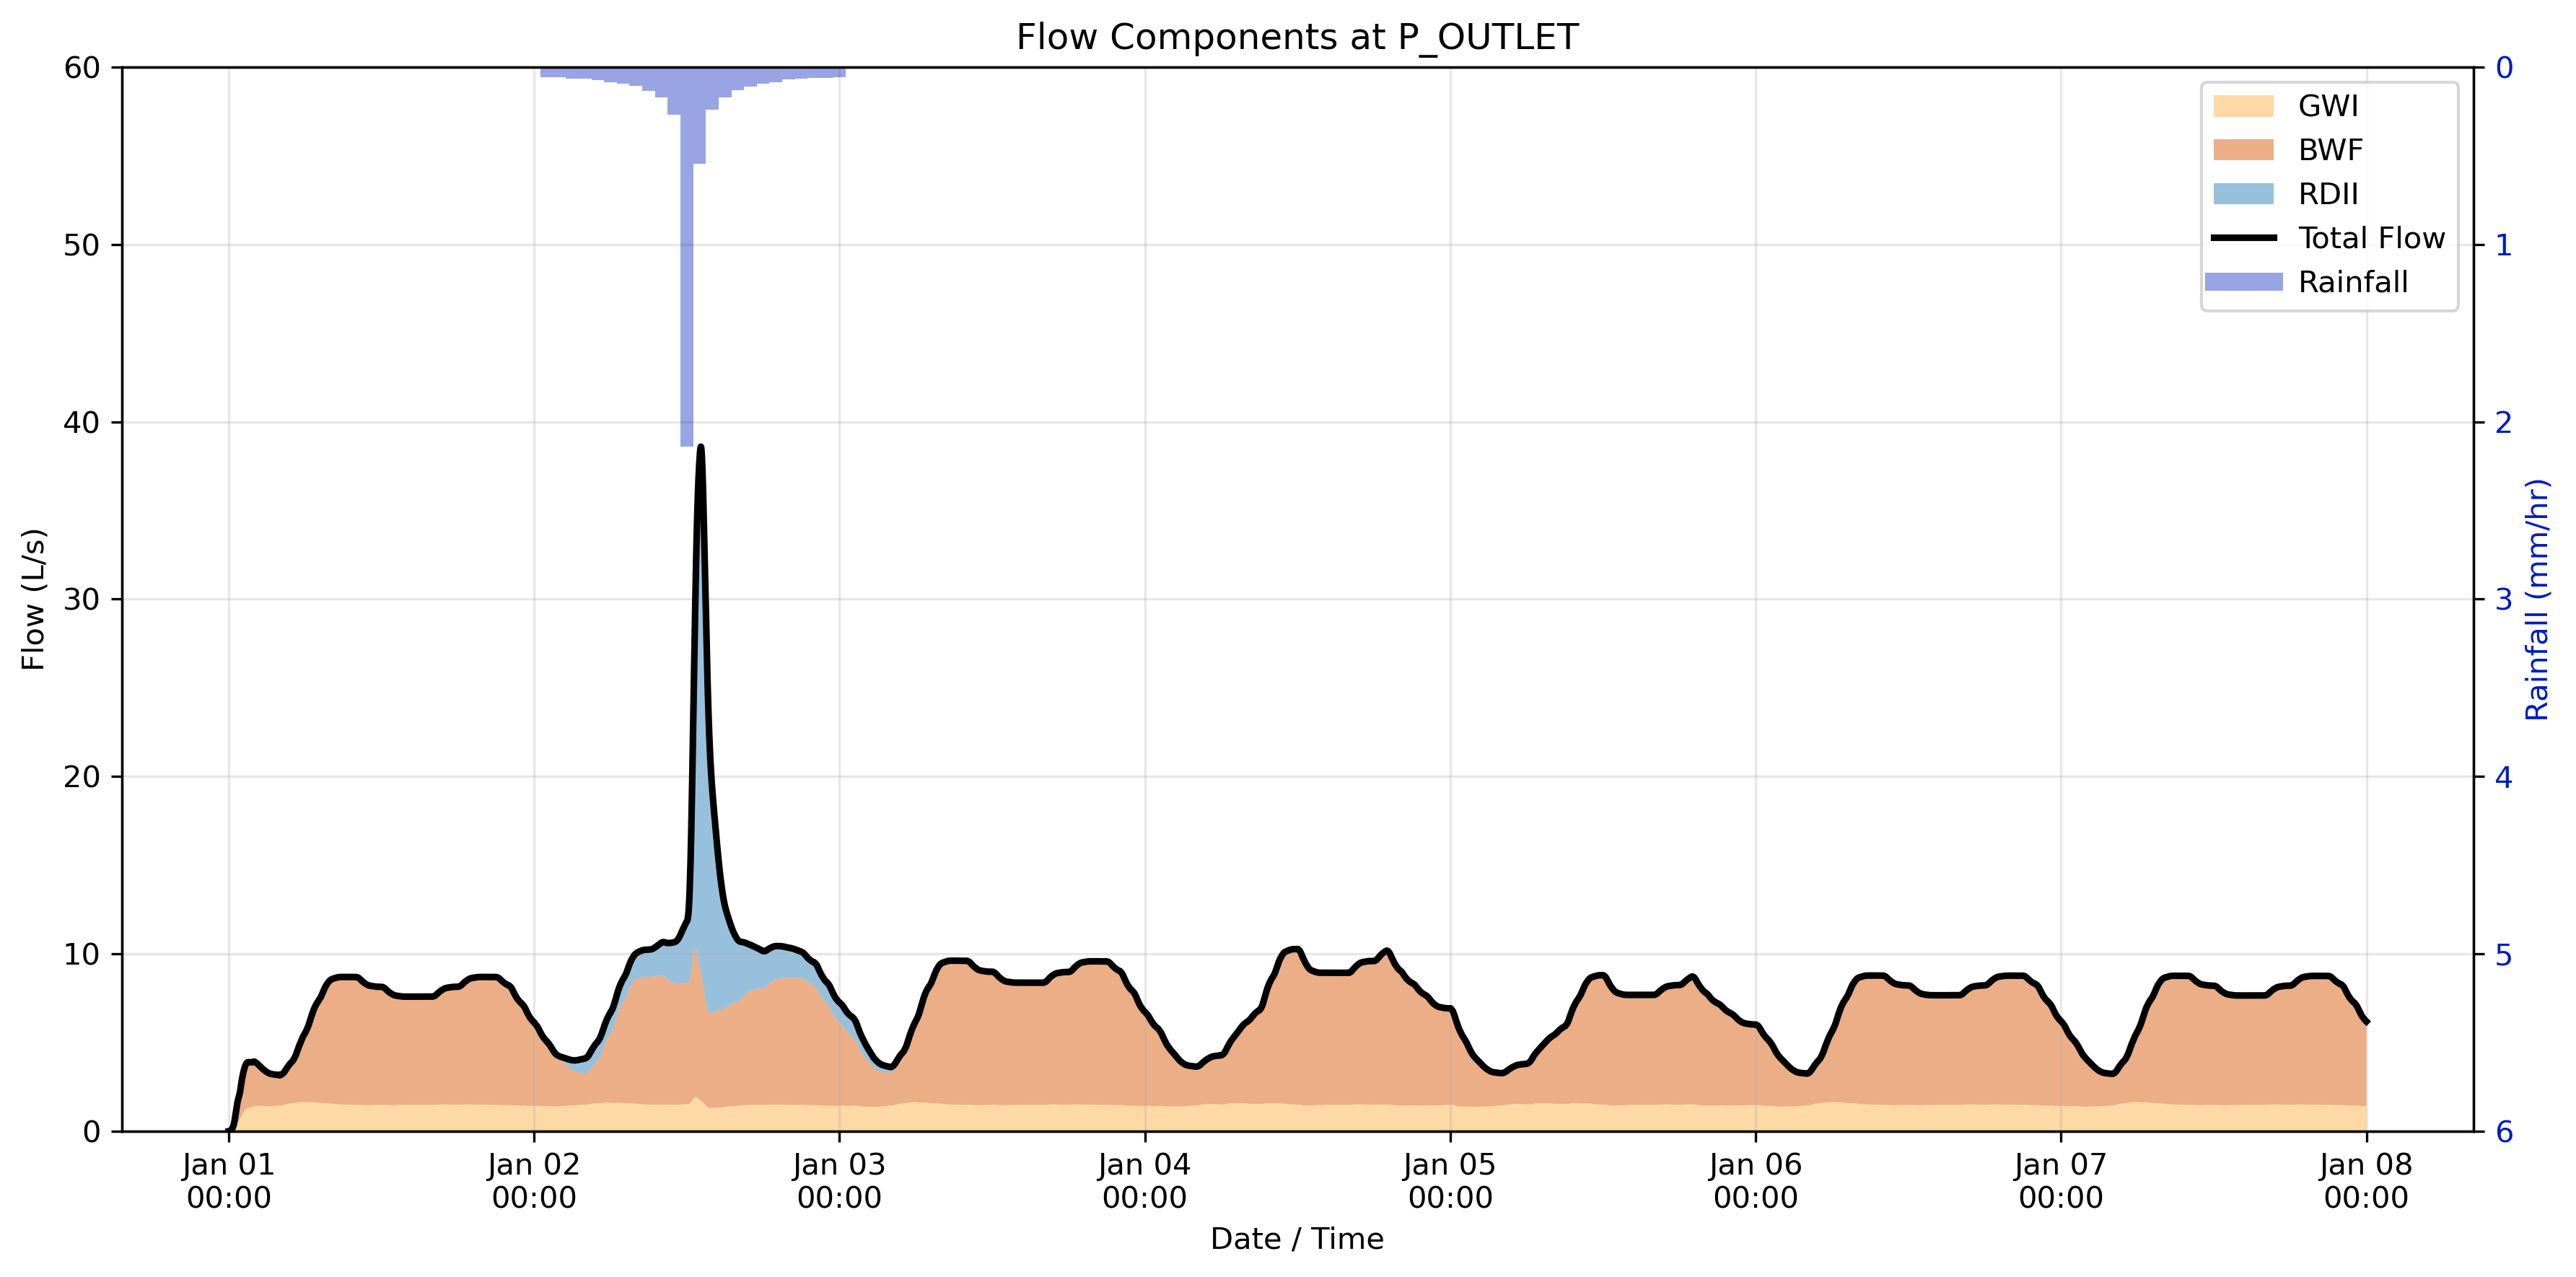

✅ Saved as flows.nc


In [78]:
fig, ax = sp.plot_flow_components_v2(
    df,
    rain=rainfall_data,
    start="2025-01-01 00:00:00",
    end="2025-01-08 00:00:00",
    flow_units="L/s",
    stack_components=True,
    flow_min=0,
    flow_max=60,
    rain_min=0,
    rain_max=6
)

# Set Datetime as index
df = df.set_index("Datetime")

# Convert DataFrame → Xarray Dataset
ds = df.to_xarray()

# Save to NetCDF
ds.to_netcdf(os.path.join(output_folder, "flows.nc"))
print("✅ Saved as flows.nc")